In [33]:
# In this notebook we will be using UMAP tools to visualize our larger catalog of galaxies
import numpy as np
import pandas as pd
from astropy.io import fits
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap
import matplotlib.pyplot as plt

In [19]:
# So lets get our eboss catalog set up first!
data_folder_name = 'data'
filename_summary = 'eboss_dr17_summary_dr2_v1.fit'
filename_weights = 'eboss_dr17_weights_dr2_v1.fit'

file_path_summary = os.path.join('..', data_folder_name, filename_summary)
file_path_weights = os.path.join('..', data_folder_name, filename_weights)

with fits.open(file_path_summary) as hdu_summary:
    eBOSS_summary = pd.DataFrame({
        'PLATE': list(hdu_summary[1].data['PLATE']),
        'MJD': list(hdu_summary[1].data['MJD']),
        'FIBER': list(hdu_summary[1].data['FIBER']),
        'PMF_STRING': list(hdu_summary[1].data['PMF_STRING']),
        'Z': list(hdu_summary[1].data['Z']),
        'Z_ERR': list(hdu_summary[1].data['Z_ERR']),
        'RA': list(hdu_summary[1].data['RA']),
        'DEC': list(hdu_summary[1].data['DEC']),
        'H_ALPHA_EW': list(hdu_summary[1].data['H_ALPHA_EW']),
        'H_BETA_EW': list(hdu_summary[1].data['H_BETA_EW']),
        'OII_EW': list(hdu_summary[1].data['OII_3727_EW']),
        'D_4000': list(hdu_summary[1].data['DN4000']),
        'D_4000_ERR': list(hdu_summary[1].data['DN4000_ERR']),
        'LICK_HDA': list(hdu_summary[1].data['LICK_HDA']),
        'LICK_HDA_ERR': list(hdu_summary[1].data['LICK_HDA_ERR']),
        'BALMERBREAK': list(hdu_summary[1].data['BALMERBREAK']),
        'BALMERBREAK_ERR': list(hdu_summary[1].data['BALMERBREAK_ERR']),
        'BPT_CLASS': list(hdu_summary[1].data['BPT_CLASS']),
        'SN_MEDIAN_ALL': list(hdu_summary[1].data['SN_MEDIAN'])
    })

# check how the pmf_string data is stored
if isinstance(eBOSS_summary['PMF_STRING'].iloc[0], bytes):
    eBOSS_summary['PMF_STRING'] = eBOSS_summary['PMF_STRING'].str.decode('utf-8') # convert to text strings

# open the FITS file then extract the data/weights
with fits.open(file_path_weights) as hdu_weights:
    data_weights = hdu_weights[1].data
    dict_weights = {name: list(data_weights[name]) for name in data_weights.dtype.names}
    df_weights = pd.DataFrame(dict_weights)

# check if the pmf_string column in the new dataframe is stored still just as raw bytes
if isinstance(df_weights['PMF_STRING'].iloc[0], bytes):
    df_weights['PMF_STRING'] = df_weights['PMF_STRING'].str.decode('utf-8')

# Merge catalogs!
eBOSS_catalog = pd.merge(eBOSS_summary, df_weights, on='PMF_STRING', suffixes=('', '_weights'))

In [20]:
# now we are going to apply some filters to our larger catalog so our UMAP plot doesn't get completely clouded up

# We will be making a redshift cut to only include z = 0.4-0.6 as well as a S/N ratio cut at >= 3 
filtered_catalog = eBOSS_catalog[
    (eBOSS_catalog['Z'] >= 0.4) & 
    (eBOSS_catalog['Z'] <= 0.6) & 
    (eBOSS_catalog['SN_MEDIAN_ALL'] >= 3)
].copy()

# I'm also going to reset the index to make sure the indexing is still correct
filtered_catalog.reset_index(drop=True, inplace=True)

In [34]:
# UPDATE: I am going to prepare our data in a more clean way, it was all getting very messy
# 1. Define the 31 interesting galaxies
interesting_galaxies = [
    (8832, 918), (4221, 271), (11376, 234), (8497, 723), (7711, 557), (10750, 178), 
    (9166, 760), (11114, 28), (10747, 766), (7388, 794), (7639, 684), (8233, 695), (8530, 222), 
    (8491, 740), (8360, 94), (8381, 531), (10912, 812), (10232, 822), (10925, 294), (7572, 656), 
    (11565, 847), (7683, 349), (11336, 284), (7306, 754), (7735, 154), (7279, 396), (10938, 81), 
    (6262, 911), (5967, 311), (8745, 354), (6453, 775)
]

# 2. Create a mask for the 31 interesting galaxies in eBOSS
pf_eBOSS = pd.MultiIndex.from_frame(eBOSS_catalog[['PLATE', 'FIBER']])
is_interesting_eBOSS = pf_eBOSS.isin(interesting_galaxies)

# 3. Quality Check Mask (same as our first notebook for now)
final_quality_check = (
    (
        ((eBOSS_catalog['Z'] > 0.1) & (eBOSS_catalog['Z'] <= 0.3) & (eBOSS_catalog['SN_MEDIAN_ALL'] < 40)) |
        ((eBOSS_catalog['Z'] > 0.3) & (eBOSS_catalog['Z'] < 0.5) & (eBOSS_catalog['SN_MEDIAN_ALL'] < 25)) |
        ((eBOSS_catalog['Z'] >= 0.5) & (eBOSS_catalog['SN_MEDIAN_ALL'] < 20))
    ) &
    (eBOSS_catalog['D_4000_ERR'] != 0) &
    (eBOSS_catalog['LICK_HDA_ERR'] != 0) &
    (eBOSS_catalog['BALMERBREAK_ERR'] > 0) &
    (eBOSS_catalog['D_4000'] / eBOSS_catalog['D_4000_ERR'] >= 10) & 
    (eBOSS_catalog['BALMERBREAK'] / eBOSS_catalog['BALMERBREAK_ERR'] >= 10) &
    (eBOSS_catalog['LICK_HDA_ERR'] < 1.5) &
    (
        ((eBOSS_catalog['Z'] <= 0.49) & (eBOSS_catalog['H_ALPHA_EW'] != -999)) | 
        ((eBOSS_catalog['Z'] > 0.49) & ((eBOSS_catalog['H_BETA_EW'] != -999) | (eBOSS_catalog['OII_EW'] != -999)))
    )
)

# Apply quality check, forcing interesting galaxies to remain because we want them all to be present on our UMAP plot
filtered_catalog = eBOSS_catalog[final_quality_check | is_interesting_eBOSS].copy()

# 4. Define UMAP feature columns
exclude_cols = [
    'PLATE', 'MJD', 'FIBER', 'PMF_STRING', 'RA', 'DEC', 'Z', 'Z_ERR', 
    'D_4000_ERR', 'LICK_HDA_ERR', 'BALMERBREAK_ERR', 'SN_MEDIAN_ALL'
]

numeric_df = filtered_catalog.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
feature_cols = [col for col in numeric_df.columns if col not in exclude_cols]

# 5. Clean dataset WITHOUT dropping any rows
clean_data = filtered_catalog.copy()

# Replace any missing flags (like -999) with NaN for UMAP's sake
X_raw = clean_data[feature_cols].replace(-999, np.nan).values

# "Impute" missing values using the column median (preserves all rows)
imputer = SimpleImputer(strategy='median') # tells python we need our missing values replaced with something, in this case for every column it calculates the median value of all galaxies that do have valid data in that column... idk if this is the best approach but it is what i am doing for now
X_imputed = imputer.fit_transform(X_raw) # scans X_raw column by column and calculates the median to be remebered, then transform goes back through and replaces all the NaN data spots with the median values

# 6. now we can scale and run UMAP
X_scaled = StandardScaler().fit_transform(X_imputed)

reducer = umap.UMAP(
    n_neighbors=30,  # tells UMAP to look at the 30 most similar galaxies for each point when deciding it's local context, higher n leads to less tiny groups while preserving distinct larger groups    
    min_dist=0.1,  # controls how tightly points are allowed to pack together, the smaller the more dense the clumps become      
    metric='euclidean',  # defines how UMAP measures distance between galaxis based on their feature, euclidean means UMAP will use the same straight line ruler formula for every feature of every galaxy pair
    random_state=42   # fixes the random number generator so UMAP produces the same exact layout everytime the code is run
)

embedding = reducer.fit_transform(X_scaled)

# check how many interesting galaxies survived just in case
pf_clean = pd.MultiIndex.from_frame(clean_data[['PLATE', 'FIBER']])
interesting_mask = pf_clean.isin(interesting_galaxies)

print(f"Total rows in UMAP analysis: {len(clean_data)}")
print(f"Total interesting galaxies present in plot: {interesting_mask.sum()} out of {len(interesting_galaxies)}")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Total rows in UMAP analysis: 607798
Total interesting galaxies present in plot: 31 out of 31


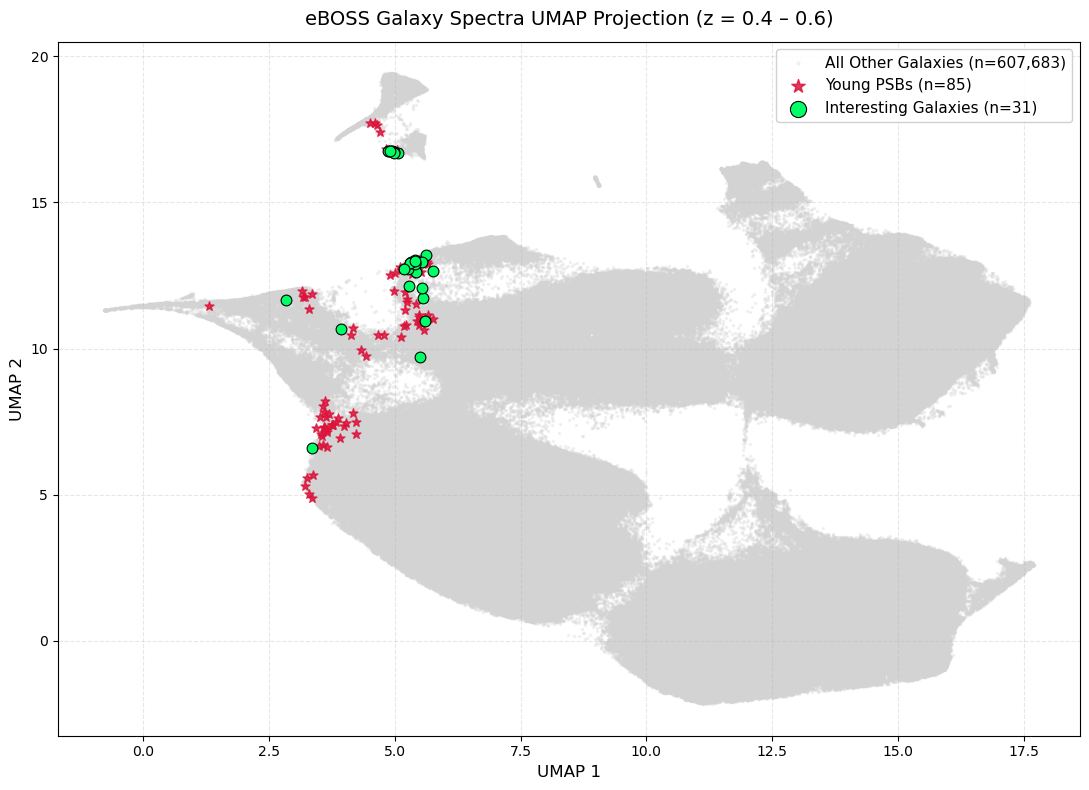

In [36]:
# now we can begin plotting with UMAP, first we have to redefine our young PSBs though
# (this is all the exact same as our first notebook)
HALPHA_YOUNG_PSB_CUT = 7.0

ypsb_mask = (
    (clean_data['BALMERBREAK'] > 0.9) & (clean_data['BALMERBREAK'] < 1.9) &
    (clean_data['LICK_HDA'] > (clean_data['BALMERBREAK'] * 5.2 - 4.7)) &
    (clean_data['BALMERBREAK'] > (clean_data['D_4000'] * 7.0 - 6.5)) &
    (clean_data['H_BETA_EW'] < 5.0) &
    (
        ((clean_data['Z'] <= 0.49) & 
         (clean_data['H_ALPHA_EW'] > -900) & 
         (clean_data['H_ALPHA_EW'] < HALPHA_YOUNG_PSB_CUT))
        |
        (clean_data['Z'] > 0.49)
    )
) & (clean_data['Z'] >= 0.4) & (clean_data['Z'] <= 0.6)

# Convert to a plain boolean array to match embedding length
ypsb_mask = ypsb_mask.values

# And we have to re-build the 31 Interesting Galaxies mask on full clean_data (because our embedding array didnt match the size of our filtered rows)
pf_index = pd.MultiIndex.from_frame(clean_data[['PLATE', 'FIBER']])
interesting_mask = pf_index.isin(interesting_galaxies)

# Andddd re-build the background mask 
background_mask = ~ypsb_mask & ~interesting_mask

# now we can actually plot
plt.figure(figsize=(11, 8))

# 1. Background galaxies: All other galaxies in the catalog in a faint color
plt.scatter(
    embedding[background_mask, 0], 
    embedding[background_mask, 1], 
    label=f'All Other Galaxies (n={background_mask.sum():,})',
    color='#d3d3d3',
    s=2, 
    alpha=0.25
)

# 2. group 1: young PSBs (red stars)
plt.scatter(
    embedding[ypsb_mask, 0], 
    embedding[ypsb_mask, 1], 
    label=f'Young PSBs (n={ypsb_mask.sum():,})',
    color='crimson',
    marker='*',
    s=45, 
    alpha=0.85,
    zorder=2
)

# 3. Group 2: All 31 interesting galaxies (green circles)
plt.scatter(
    embedding[interesting_mask, 0], 
    embedding[interesting_mask, 1], 
    label=f'Interesting Galaxies (n={interesting_mask.sum()})',
    color='#00FF66',
    edgecolor='black',
    linewidth=0.8,
    marker='o',
    s=60, 
    alpha=1.0,
    zorder=3
)

# plot formatting and labels
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('eBOSS Galaxy Spectra UMAP Projection (z = 0.4 – 0.6)', fontsize=14, pad=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Legend 
plt.legend(
    loc='upper right', 
    fontsize=11, 
    markerscale=1.5, 
    framealpha=0.9
)

plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


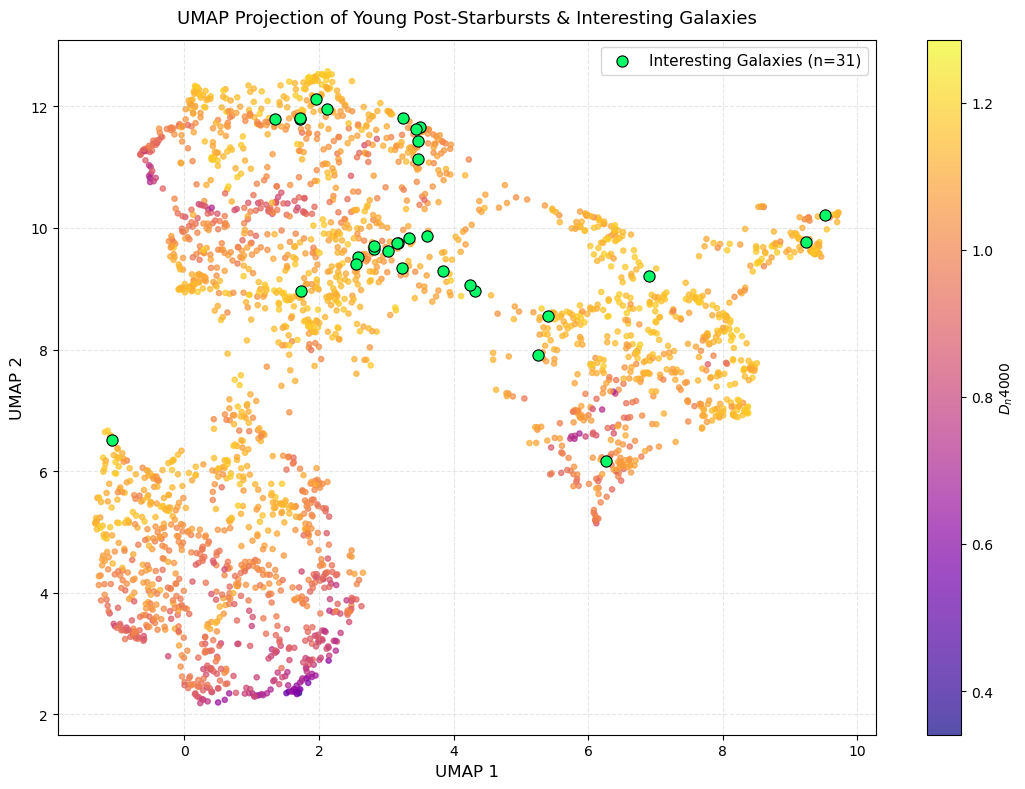

In [38]:
# now lets make a UMAP plot of just our young PSB galaxies with our interesting galaxies highlighted
# we have to repeat a few steps from our previous block here

interesting_galaxies = [
    (8832, 918), (4221, 271), (11376, 234), (8497, 723), (7711, 557), (10750, 178), 
    (9166, 760), (11114, 28), (10747, 766), (7388, 794), (7639, 684), (8233, 695), (8530, 222), 
    (8491, 740), (8360, 94), (8381, 531), (10912, 812), (10232, 822), (10925, 294), (7572, 656), 
    (11565, 847), (7683, 349), (11336, 284), (7306, 754), (7735, 154), (7279, 396), (10938, 81), 
    (6262, 911), (5967, 311), (8745, 354), (6453, 775)
]

standard_outlier_mask = (
    (eBOSS_catalog['LICK_HDA'] > -5) & (eBOSS_catalog['LICK_HDA'] < 13) & 
    (eBOSS_catalog['D_4000'] > 0) & (eBOSS_catalog['D_4000'] < 2.5) & 
    (eBOSS_catalog['BALMERBREAK'] > 0) & (eBOSS_catalog['BALMERBREAK'] < 3.5) 
)

line_outlier_mask = (
    ((eBOSS_catalog['Z'] <= 0.49) & 
     (eBOSS_catalog['H_ALPHA_EW'] > 0) & 
     (eBOSS_catalog['H_BETA_EW'] > 0)
    )
    |
    (
        (eBOSS_catalog['Z'] > 0.49) & 
        (
          (eBOSS_catalog['H_BETA_EW'] > 0) | 
          (eBOSS_catalog['OII_EW'] > 0)
        )
     )
)

filtered_base = eBOSS_catalog[standard_outlier_mask & line_outlier_mask].copy()

HALPHA_YOUNG_PSB_CUT = 7.0

young_psb_mask = (
    (filtered_base['BALMERBREAK'] > 0.9) & (filtered_base['BALMERBREAK'] < 1.9) &
    (filtered_base['LICK_HDA'] > (filtered_base['BALMERBREAK'] * 5.2 - 4.7)) &
    (filtered_base['BALMERBREAK'] > (filtered_base['D_4000'] * 7.0 - 6.5)) &
    (filtered_base['H_BETA_EW'] < 5.0) &
    (
        ((filtered_base['Z'] <= 0.49) & 
         (filtered_base['H_ALPHA_EW'] > -900) & 
         (filtered_base['H_ALPHA_EW'] < HALPHA_YOUNG_PSB_CUT))
        |
        (filtered_base['Z'] > 0.49)
    )
)

pf_base = pd.MultiIndex.from_frame(filtered_base[['PLATE', 'FIBER']])
is_interesting_base = pf_base.isin(interesting_galaxies)

young_psb_catalog = filtered_base[young_psb_mask | is_interesting_base].copy() # this is really the only change from our last code block, we are just looking at our young psbs now
young_psb_catalog.reset_index(drop=True, inplace=True)

exclude_cols = [
    'PLATE', 'MJD', 'FIBER', 'PMF_STRING', 'RA', 'DEC', 'Z', 'Z_ERR', 
    'D_4000_ERR', 'LICK_HDA_ERR', 'BALMERBREAK_ERR', 'SN_MEDIAN_ALL', 'PSB_CLASS'
]

numeric_df = young_psb_catalog.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
feature_cols = [col for col in numeric_df.columns if col not in exclude_cols]

clean_young_psb = young_psb_catalog.copy()

X_raw = clean_young_psb[feature_cols].replace(-999, np.nan).values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

X_scaled = StandardScaler().fit_transform(X_imputed)

# now we can begin using UMAP again
reducer_psb = umap.UMAP(
    n_neighbors=15,   # I made the neighbor size smaller here because our galaxies should, in theory, be all more similar and we just have less of them in general  
    min_dist=0.1,        
    metric='euclidean',  
    random_state=42
)

embedding_psb = reducer_psb.fit_transform(X_scaled)

# here we build masks for visuals on the plot
pf_psb = pd.MultiIndex.from_frame(clean_young_psb[['PLATE', 'FIBER']])
interesting_mask_psb = pf_psb.isin(interesting_galaxies)

plt.figure(figsize=(11, 8))

# background Young PSBs colored by D_4000 for now, we can change this easily though
scatter = plt.scatter(
    embedding_psb[:, 0], 
    embedding_psb[:, 1], 
    c=clean_young_psb['D_4000'], 
    cmap='plasma', 
    s=14, 
    alpha=0.7,
    zorder=1
)

# highlight 31 interesting galaxies in green
plt.scatter(
    embedding_psb[interesting_mask_psb, 0], 
    embedding_psb[interesting_mask_psb, 1], 
    color='#00FF66',
    edgecolor='black',
    linewidth=0.8,
    marker='o',
    s=65, 
    alpha=1.0,
    label=f'Interesting Galaxies (n={interesting_mask_psb.sum()})',
    zorder=3
)

plt.colorbar(scatter, label=r'$D_n4000$')
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP Projection of Young Post-Starbursts & Interesting Galaxies', fontsize=13, pad=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

Features used for Continuum UMAP (4 total):
['PLATE_weights', 'MJD_weights', 'FIBER_weights', 'Z_weights']



/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


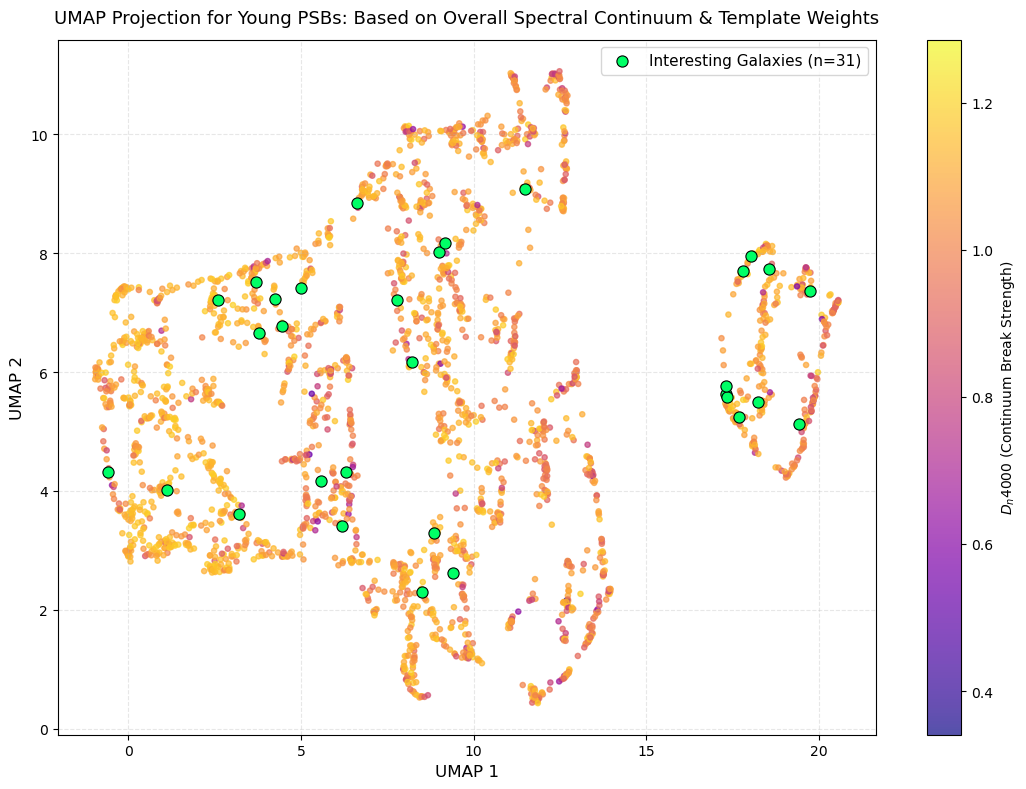

In [42]:
# now, based on Christy's suggestion, I will make a UMAP projection based on the galaxies overall spectra continuum instead of just emission/absorption lines
# again... we start by redefining everything as we have in the past two blocks

interesting_galaxies = [
    (8832, 918), (4221, 271), (11376, 234), (8497, 723), (7711, 557), (10750, 178), 
    (9166, 760), (11114, 28), (10747, 766), (7388, 794), (7639, 684), (8233, 695), (8530, 222), 
    (8491, 740), (8360, 94), (8381, 531), (10912, 812), (10232, 822), (10925, 294), (7572, 656), 
    (11565, 847), (7683, 349), (11336, 284), (7306, 754), (7735, 154), (7279, 396), (10938, 81), 
    (6262, 911), (5967, 311), (8745, 354), (6453, 775)
]

standard_outlier_mask = (
    (eBOSS_catalog['LICK_HDA'] > -5) & (eBOSS_catalog['LICK_HDA'] < 13) & 
    (eBOSS_catalog['D_4000'] > 0) & (eBOSS_catalog['D_4000'] < 2.5) & 
    (eBOSS_catalog['BALMERBREAK'] > 0) & (eBOSS_catalog['BALMERBREAK'] < 3.5) 
)

line_outlier_mask = (
    ((eBOSS_catalog['Z'] <= 0.49) & 
     (eBOSS_catalog['H_ALPHA_EW'] > 0) & 
     (eBOSS_catalog['H_BETA_EW'] > 0)
    )
    |
    (
        (eBOSS_catalog['Z'] > 0.49) & 
        (
          (eBOSS_catalog['H_BETA_EW'] > 0) | 
          (eBOSS_catalog['OII_EW'] > 0)
        )
     )
)

filtered_base = eBOSS_catalog[standard_outlier_mask & line_outlier_mask].copy()

HALPHA_YOUNG_PSB_CUT = 7.0

young_psb_mask = (
    (filtered_base['BALMERBREAK'] > 0.9) & (filtered_base['BALMERBREAK'] < 1.9) &
    (filtered_base['LICK_HDA'] > (filtered_base['BALMERBREAK'] * 5.2 - 4.7)) &
    (filtered_base['BALMERBREAK'] > (filtered_base['D_4000'] * 7.0 - 6.5)) &
    (filtered_base['H_BETA_EW'] < 5.0) &
    (
        ((filtered_base['Z'] <= 0.49) & 
         (filtered_base['H_ALPHA_EW'] > -900) & 
         (filtered_base['H_ALPHA_EW'] < HALPHA_YOUNG_PSB_CUT))
        |
        (filtered_base['Z'] > 0.49)
    )
)

pf_base = pd.MultiIndex.from_frame(filtered_base[['PLATE', 'FIBER']])
is_interesting_base = pf_base.isin(interesting_galaxies)

young_psb_catalog = filtered_base[young_psb_mask | is_interesting_base].copy()
young_psb_catalog.reset_index(drop=True, inplace=True)

# here is our major change, we only select continuum/template features for UMAP 
exclude_line_and_meta_cols = [
    'PLATE', 'MJD', 'FIBER', 'PMF_STRING', 'RA', 'DEC', 'Z', 'Z_ERR', 
    'D_4000_ERR', 'LICK_HDA_ERR', 'BALMERBREAK_ERR', 'SN_MEDIAN_ALL', 'PSB_CLASS',
    'D_4000', 'BALMERBREAK', 'LICK_HDA', 'H_ALPHA_EW', 'H_BETA_EW', 'OII_EW',
    'H_ALPHA_EW_ERR', 'H_BETA_EW_ERR', 'OII_EW_ERR'
]

# Get remaining numeric columns 
numeric_df = young_psb_catalog.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
continuum_feature_cols = [col for col in numeric_df.columns if col not in exclude_line_and_meta_cols]

print(f"Features used for Continuum UMAP ({len(continuum_feature_cols)} total):\n{continuum_feature_cols}\n")

clean_young_psb = young_psb_catalog.copy()

X_raw_cont = clean_young_psb[continuum_feature_cols].replace(-999, np.nan).values
imputer = SimpleImputer(strategy='median')
X_imputed_cont = imputer.fit_transform(X_raw_cont)

X_scaled_cont = StandardScaler().fit_transform(X_imputed_cont)

# now we start using UMAP againnn
reducer_continuum = umap.UMAP(
    n_neighbors=15,     
    min_dist=0.1,        
    metric='euclidean',  
    random_state=42
)

embedding_continuum = reducer_continuum.fit_transform(X_scaled_cont)

pf_psb = pd.MultiIndex.from_frame(clean_young_psb[['PLATE', 'FIBER']])
interesting_mask_psb = pf_psb.isin(interesting_galaxies)

plt.figure(figsize=(11, 8))

# background Young PSBs colored by D_4000 still to track continuum slope/age 
scatter = plt.scatter(
    embedding_continuum[:, 0], 
    embedding_continuum[:, 1], 
    c=clean_young_psb['D_4000'], 
    cmap='plasma', 
    s=14, 
    alpha=0.7,
    zorder=1
)

# I'll still highlight the 31 interesting galaxies as well for now
plt.scatter(
    embedding_continuum[interesting_mask_psb, 0], 
    embedding_continuum[interesting_mask_psb, 1], 
    color='#00FF66',
    edgecolor='black',
    linewidth=0.8,
    marker='o',
    s=65, 
    alpha=1.0,
    label=f'Interesting Galaxies (n={interesting_mask_psb.sum()})',
    zorder=3
)

plt.colorbar(scatter, label=r'$D_n4000$ (Continuum Break Strength)')
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP Projection for Young PSBs: Based on Overall Spectral Continuum & Template Weights', fontsize=13, pad=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# n_neighbor changes NOTED
# color code by redshifts second plot
# vetted indices on websites using partial labeling 
# highlight our interesting galaxies NOTED
# let UMAP use the entire spectra instead of just emission and absorption lines NOTED 
# start drafting up final essays sophomore research fellowship 
# astronomy 600 credits or getting paid for research talk to evan heintz 
# abstract deadline october 1st for salt lake
# line indices *** try putting into UMAP on their own (redshift independent) then throw interesting galaxies 
